In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns


In [4]:
import matplotlib.pyplot as plt

In [8]:
housing=fetch_california_housing()
df=pd.DataFrame(housing.data,columns=housing.feature_names)
print(df)


       MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
0      8.3252      41.0  6.984127  ...  2.555556     37.88    -122.23
1      8.3014      21.0  6.238137  ...  2.109842     37.86    -122.22
2      7.2574      52.0  8.288136  ...  2.802260     37.85    -122.24
3      5.6431      52.0  5.817352  ...  2.547945     37.85    -122.25
4      3.8462      52.0  6.281853  ...  2.181467     37.85    -122.25
...       ...       ...       ...  ...       ...       ...        ...
20635  1.5603      25.0  5.045455  ...  2.560606     39.48    -121.09
20636  2.5568      18.0  6.114035  ...  3.122807     39.49    -121.21
20637  1.7000      17.0  5.205543  ...  2.325635     39.43    -121.22
20638  1.8672      18.0  5.329513  ...  2.123209     39.43    -121.32
20639  2.3886      16.0  5.254717  ...  2.616981     39.37    -121.24

[20640 rows x 8 columns]


In [7]:
print(housing)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [9]:
print(df['AveRooms'].notnull().sum())

20640


In [10]:
column="AveRooms"

In [11]:
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)

IQR = Q3-Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"Column={column}")
print(f"IQR:{IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")

Column=AveRooms
IQR:1.61
Lower Bound: 2.02 | Upper Bound: 8.47


In [15]:
outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)] #figure this out
print(f"Outlier Rows:{len(outliers)}")
print(f"Total Rows: {len(df)}")

Outlier Rows:511
Total Rows: 20640


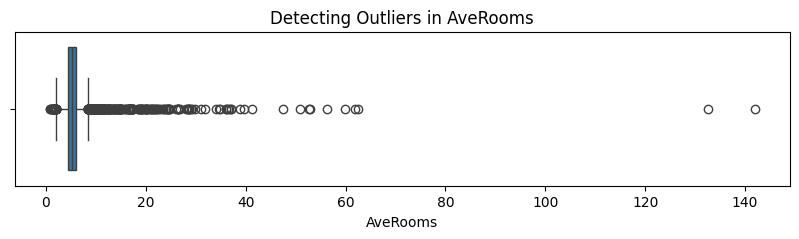

In [16]:
plt.figure(figsize=(10,2))
sns.boxplot(x=df[column])
plt.title(f"Detecting Outliers in {column}")
plt.show()

In [18]:
df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
print(f"Shape Before:{df.shape}")
print(f"Shape After: {df_cleaned.shape}")


Shape Before:(20640, 8)
Shape After: (20129, 8)


Text(0.5, 1.0, 'No Outliers')

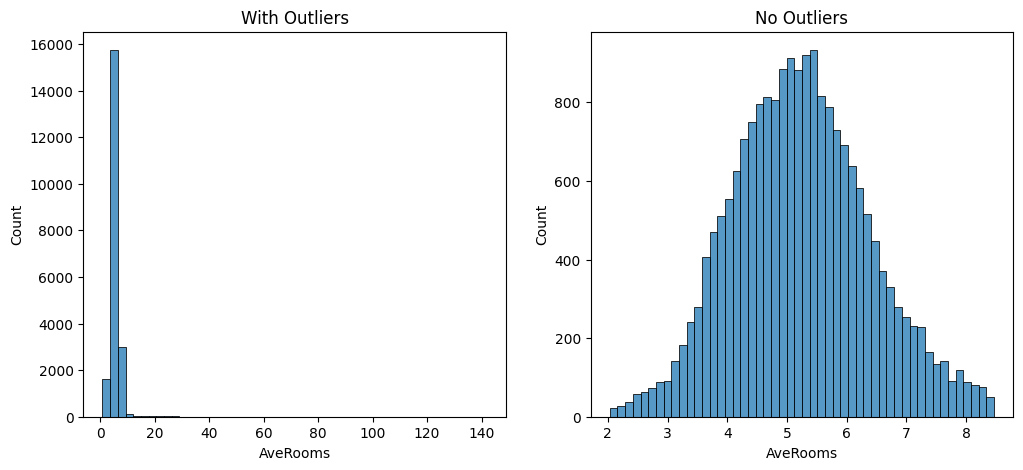

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5)) #creates grid ax[0] and ax[1]

sns.histplot(df[column],bins=50,ax=ax[0]).set_title("With Outliers") #bins divides the data into 50 evenly spaced bars



sns.histplot(df_cleaned[column],bins=50,ax=ax[1]).set_title("No Outliers")

In [24]:
column1='AveBedrms'
Q1 = df[column1].quantile(0.25)
Q3 = df[column1].quantile(0.75)

IQR = Q3-Q1

upper_bound1 = Q3 + 1.5 * IQR
lower_bound1 = Q1 - 1.5 * IQR

print(f"Column={column1}")
print(f"IQR:{IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")

Column=AveBedrms
IQR:0.09
Lower Bound: 0.87 | Upper Bound: 1.24


In [25]:
updated_df=df[(df[column1]>=lower_bound1)&(df[column1]<=upper_bound1)]


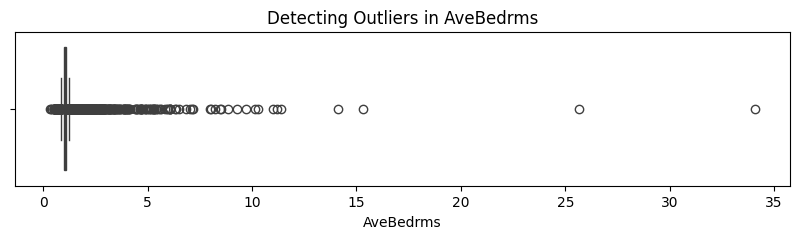

In [29]:
plt.figure(figsize=(10,2))
sns.boxplot(x=df[column1])
plt.title(f"Detecting Outliers in {column1}")
plt.show()

In [30]:
print(f"Shape Before:{df.shape}")
print(f"Shape After: {updated_df.shape}")

Shape Before:(20640, 8)
Shape After: (19216, 8)


Text(0.5, 1.0, 'No Outliers')

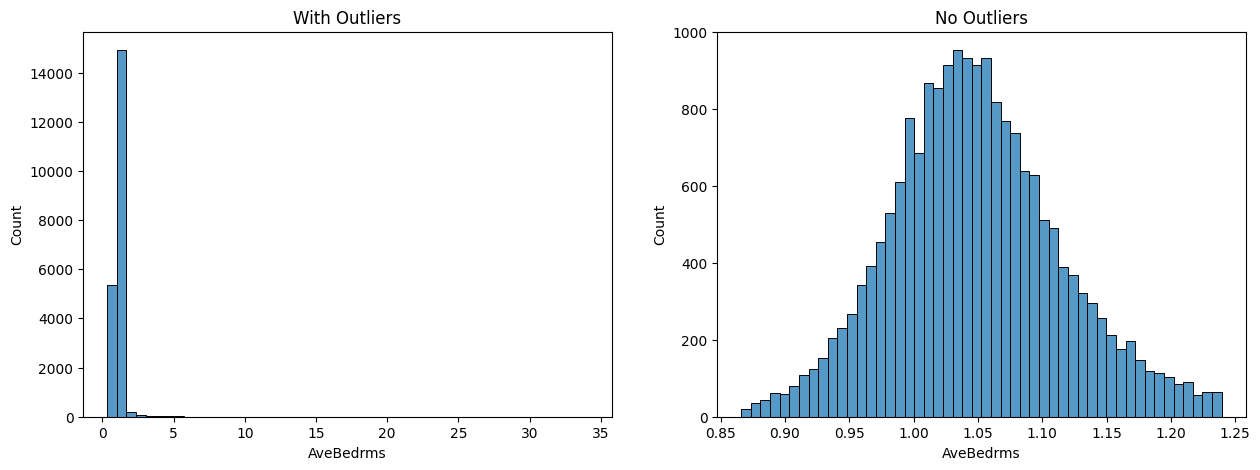

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15,5)) #creates grid ax[0] and ax[1]

sns.histplot(df[column1],bins=50,ax=ax[0]).set_title("With Outliers") #bins divides the data into 50 evenly spaced bars



sns.histplot(updated_df[column1],bins=50,ax=ax[1]).set_title("No Outliers")